# 2 · Model — train, evaluate, diagnose

Everything model-side for the CHIRPS 0.25° → 0.05° self-super-resolution GAN.
Run `01_data_pipeline.ipynb` first; this notebook starts from `paired_data.npz`.

| Section | Produces |
|---|---|
| 1 · Data & scaling | chronological train/val/test splits |
| 2 · Model | `Generator`, `Discriminator` |
| 3 · Training | `results/checkpoints/best.pt`, `history.json`, `scaler.json` |
| 4 · Evaluation | `results/test_metrics.json` |
| 5 · Prediction maps | `figures/predicted_vs_actual.png` |
| 6 · Diagnostics | `figures/diagnostics.png`, `results/diagnostics.json` |

**Training is off by default** (`RETRAIN = False`) so running all cells won't
overwrite the checkpoint you already have. Sections 4–6 load `best.pt` from disk
either way.

In [1]:
import json
import time
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

CWD = Path.cwd()
PROJECT = CWD.parent if CWD.name == "notebooks" else CWD

DATA = PROJECT / "Downscaling"
RESULTS = PROJECT / "results"
FIGURES = PROJECT / "figures"
CKPT_DIR = RESULTS / "checkpoints"
PAIRED_DATA = DATA / "paired_data.npz"
STATE_GEOJSON = DATA / "state.geojson"

for d in (RESULTS, FIGURES, CKPT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# blocks entirely outside the mask are all-NaN by design; the NaN result is wanted.
warnings.filterwarnings("ignore", message="Degrees of freedom <= 0")
warnings.filterwarnings("ignore", message="Mean of empty slice")

FACTOR = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE, "| torch", torch.__version__)

device: cuda | torch 2.13.0+cu130


## 1 · Data and scaling

Rainfall is heavily right-skewed, so values go through `log1p` and are then mapped
to `[-1, 1]`. The scale is fitted on the **training years only** — no leakage.

The split is chronological, not random: daily rainfall is strongly autocorrelated,
so shuffling days across the split would leak neighbouring-day information.

> One consequence of the fixed scale worth knowing: `Scaler.inverse` clips to
> `[-1, 1]`, which caps any prediction at the training-set maximum
> (578.37 mm/day). Fine for this test set, tight for a wetter one.

In [2]:
class Scaler:
    def __init__(self, scale):
        self.scale = scale

    @classmethod
    def fit(cls, hr_train):
        return cls(float(np.log1p(hr_train.max())))

    def transform(self, x):
        return np.log1p(np.clip(x, 0, None)) / self.scale * 2.0 - 1.0

    def inverse(self, y):
        y = np.clip(y, -1.0, 1.0)
        return np.expm1((y + 1.0) / 2.0 * self.scale)


class SRPairDataset(Dataset):
    def __init__(self, lr, hr, mask_lr, mask_hr, scaler):
        self.lr = scaler.transform(lr).astype("float32")
        self.hr = scaler.transform(hr).astype("float32")
        self.mask_lr = mask_lr.astype("float32")
        self.mask_hr = mask_hr.astype("float32")

    def __len__(self):
        return len(self.lr)

    def __getitem__(self, i):
        x = np.stack([self.lr[i], self.mask_lr], axis=0)  # (2, 18, 10)
        y = self.hr[i][None, :, :]                        # (1, 90, 50)
        return torch.from_numpy(x), torch.from_numpy(y)

In [3]:
d = np.load(PAIRED_DATA, allow_pickle=True)
lr, hr = d["lr"], d["hr"]
mask_lr, mask_hr = d["mask_lr"], d["mask_hr"]
dates = d["dates"]
lat_hr, lon_hr, lat_lr, lon_lr = d["lat_hr"], d["lon_hr"], d["lat_lr"], d["lon_lr"]
mask_bool = mask_hr.astype(bool)

years = dates.astype("datetime64[Y]").astype(int) + 1970
idx = {"train": years <= 2018,
       "val": (years >= 2019) & (years <= 2021),
       "test": years >= 2022}

scaler = Scaler.fit(hr[idx["train"]])
splits = {k: SRPairDataset(lr[v], hr[v], mask_lr, mask_hr, scaler) for k, v in idx.items()}

mask_hr_t = torch.from_numpy(mask_hr.astype("float32"))[None, None].to(DEVICE)
mask_lr_t = torch.from_numpy(mask_lr.astype("float32"))[None, None].to(DEVICE)

for k, v in idx.items():
    print(f"{k:5s} {v.sum():5d} days   {str(dates[v][0])[:10]} to {str(dates[v][-1])[:10]}")
print(f"\nscale = {scaler.scale:.3f}  ->  output ceiling {np.expm1(scaler.scale):.1f} mm/day")

train  8401 days   1996-01-01 to 2018-12-31
val    1096 days   2019-01-01 to 2021-12-31
test   1461 days   2022-01-01 to 2025-12-31

scale = 6.362  ->  output ceiling 578.4 mm/day


## 2 · Model

**Generator** — SRResNet-style. Residual blocks extract features at low resolution,
then a single `PixelShuffle(5)` does the whole 5× upsample in one step (PixelShuffle
handles any integer factor, not just powers of 2), followed by refinement convs at
high resolution. A global skip adds the nearest-upsampled input, so the network only
has to learn the *added* fine detail rather than the whole field.

**Discriminator** — PatchGAN at high resolution, conditioned on the upsampled
low-res field (pix2pix-style), so it checks the output is both realistic *and*
consistent with the actual input rather than just generically CHIRPS-like.

In [4]:
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1),
            nn.InstanceNorm2d(ch, affine=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, 3, padding=1),
            nn.InstanceNorm2d(ch, affine=True),
        )

    def forward(self, x):
        return x + self.body(x)


class Generator(nn.Module):
    def __init__(self, in_ch=2, base_ch=64, n_blocks=8):
        super().__init__()
        self.head = nn.Sequential(nn.Conv2d(in_ch, base_ch, 5, padding=2), nn.ReLU(inplace=True))
        self.body = nn.Sequential(*[ResBlock(base_ch) for _ in range(n_blocks)])
        self.body_out = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, 3, padding=1), nn.InstanceNorm2d(base_ch, affine=True)
        )
        self.upsample = nn.Sequential(
            nn.Conv2d(base_ch, base_ch * FACTOR * FACTOR, 3, padding=1),
            nn.PixelShuffle(FACTOR),
            nn.ReLU(inplace=True),
        )
        self.refine = nn.Sequential(nn.Conv2d(base_ch, base_ch, 3, padding=1), nn.ReLU(inplace=True))
        self.tail = nn.Conv2d(base_ch, 1, 5, padding=2)

    def forward(self, x):
        lr_channel, mask_channel = x[:, :1], x[:, 1:2]

        h = self.head(x)
        h = h + self.body_out(self.body(h))
        h = self.upsample(h)
        h = self.refine(h)
        residual = self.tail(h)

        lr_upsampled = F.interpolate(lr_channel, scale_factor=FACTOR, mode="nearest")
        mask_up = F.interpolate(mask_channel, scale_factor=FACTOR, mode="nearest")

        out = torch.clamp(lr_upsampled + residual, -1.0, 1.0)
        return out * mask_up + (-1.0) * (1.0 - mask_up)  # -1 = zero rain, see Scaler


class Discriminator(nn.Module):
    """PatchGAN at HR resolution, conditioned on the nearest-upsampled LR."""

    def __init__(self, cond_ch=1, base_ch=64):
        super().__init__()

        def block(cin, cout, stride=2, norm=True):
            layers = [nn.Conv2d(cin, cout, 4, stride=stride, padding=1)]
            if norm:
                layers.append(nn.InstanceNorm2d(cout, affine=True))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(cond_ch + 1, base_ch, norm=False),
            *block(base_ch, base_ch * 2),
            *block(base_ch * 2, base_ch * 4, stride=1),
            nn.Conv2d(base_ch * 4, 1, 4, padding=1),
        )

    def forward(self, lr_cond_upsampled, hr):
        return self.model(torch.cat([lr_cond_upsampled, hr], dim=1))

In [5]:
# shape smoke test
_g, _d = Generator(), Discriminator()
_x = torch.randn(4, 2, 18, 10)
_x[:, 1:2] = (torch.rand(4, 1, 18, 10) > 0.5).float()
_out = _g(_x)
_patch = _d(F.interpolate(_x[:, :1], scale_factor=FACTOR, mode="nearest"), _out)

print(f"generator     (4,2,18,10) -> {tuple(_out.shape)}   range [{_out.min():.2f}, {_out.max():.2f}]")
print(f"discriminator             -> {tuple(_patch.shape)}")
print(f"params: generator {sum(p.numel() for p in _g.parameters()):,} | "
      f"discriminator {sum(p.numel() for p in _d.parameters()):,}")
del _g, _d, _x, _out, _patch

generator     (4,2,18,10) -> (4, 1, 90, 50)   range [-1.00, 1.00]
discriminator             -> (4, 1, 20, 10)
params: generator 1,594,945 | discriminator 662,721


## 3 · Training

Three terms on the generator:

| Term | Weight | What it does |
|---|---|---|
| Adversarial (BCE) | 1 | PatchGAN realism, conditioned on the upsampled LR |
| Masked L1 | 100 | Pixel accuracy at high resolution — the workhorse |
| Downsample-consistency | 50 | Average-pool the output 5×5 and compare to the LR input |

> **Known defect — the consistency term is measured in the wrong space.**
> The LR field is a 5×5 mean in **mm/day**, but `downsample_consistency` pools in
> **log1p-scaled** units. Since `log1p` is concave, `mean(log1p(x)) ≠ log1p(mean(x))`,
> so a *perfect* generator would still score **0.1065** on this loss — section 6
> measures it. On top of that, `avg_pool2d` divides by 25 while the LR field divides
> by the valid-cell count, which disagrees on 45 of 78 blocks.
>
> Both are left as-is here so this notebook reproduces the existing checkpoint.
> See `docs/REPORT.md` findings 1 and 2 before changing them.

In [6]:
L1_LAMBDA = 100.0
CONSIST_LAMBDA = 50.0


def masked_l1(pred, target, mask):
    diff = torch.abs(pred - target) * mask
    denom = mask.expand_as(pred).sum()
    return diff.sum() / denom.clamp(min=1)


def downsample_consistency(fake_hr, lr_input, mask_lr_t):
    pooled = F.avg_pool2d(fake_hr, kernel_size=FACTOR)
    return masked_l1(pooled, lr_input, mask_lr_t)


@torch.no_grad()
def val_loss(g, loader):
    g.eval()
    total, n = 0.0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        total += masked_l1(g(x), y, mask_hr_t).item() * x.size(0)
        n += x.size(0)
    g.train()
    return total / n

In [7]:
def train(epochs=150, batch_size=32, lr_rate=2e-4):
    train_loader = DataLoader(splits["train"], batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(splits["val"], batch_size=batch_size, shuffle=False, num_workers=2)

    g, dsc = Generator().to(DEVICE), Discriminator().to(DEVICE)
    opt_g = torch.optim.Adam(g.parameters(), lr=lr_rate, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(dsc.parameters(), lr=lr_rate, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()

    (RESULTS / "scaler.json").write_text(json.dumps({"scale": scaler.scale}))

    history, best_val = [], float("inf")
    for epoch in range(epochs):
        t0 = time.time()
        sums = dict(g_loss=0.0, d_loss=0.0, train_l1=0.0, consist=0.0)
        n_seen = 0

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            b = x.size(0)
            lr_up = F.interpolate(x[:, :1], scale_factor=FACTOR, mode="nearest")

            # --- discriminator
            with torch.no_grad():
                fake = g(x)
            pred_real, pred_fake = dsc(lr_up, y), dsc(lr_up, fake)
            d_loss = 0.5 * (bce(pred_real, torch.ones_like(pred_real))
                            + bce(pred_fake, torch.zeros_like(pred_fake)))
            opt_d.zero_grad()
            d_loss.backward()
            opt_d.step()

            # --- generator
            fake = g(x)
            pred_fake_for_g = dsc(lr_up, fake)
            adv_loss = bce(pred_fake_for_g, torch.ones_like(pred_fake_for_g))
            l1_loss = masked_l1(fake, y, mask_hr_t)
            consist_loss = downsample_consistency(fake, x[:, :1], mask_lr_t)
            g_loss = adv_loss + L1_LAMBDA * l1_loss + CONSIST_LAMBDA * consist_loss

            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

            for k, v in zip(sums, (g_loss, d_loss, l1_loss, consist_loss)):
                sums[k] += v.item() * b
            n_seen += b

        row = {"epoch": epoch, **{k: v / n_seen for k, v in sums.items()},
               "val_l1": val_loss(g, val_loader), "seconds": time.time() - t0}
        history.append(row)
        print(f"epoch {epoch:3d} | g_loss {row['g_loss']:.4f} d_loss {row['d_loss']:.4f} "
              f"train_l1 {row['train_l1']:.4f} consist {row['consist']:.4f} "
              f"val_l1 {row['val_l1']:.4f} ({row['seconds']:.1f}s)")

        ck = {"g": g.state_dict(), "epoch": epoch, "best_val": best_val}
        torch.save(ck, CKPT_DIR / "last.pt")
        if row["val_l1"] < best_val:
            best_val = ck["best_val"] = row["val_l1"]
            torch.save(ck, CKPT_DIR / "best.pt")

        (RESULTS / "history.json").write_text(json.dumps(history))

    print("done. best val_l1:", best_val)
    return history

In [8]:
RETRAIN = False  # True overwrites results/checkpoints/best.pt — ~10 min on GPU

if RETRAIN:
    history = train(epochs=150)
else:
    history = json.loads((RESULTS / "history.json").read_text())
    print(f"loaded existing history: {len(history)} epochs (set RETRAIN=True to train again)")

loaded existing history: 150 epochs (set RETRAIN=True to train again)


### Training curves

Validation loss bottoms out at **epoch 18** and climbs for the remaining 131 — 87% of
the run made the model worse. Meanwhile the consistency term rises steadily, because
the model is getting *more* accurate and the log-space mismatch above means accuracy
and that loss pull in opposite directions.

Checkpoint selection also uses validation L1, a pixel metric — which picks the epoch
where the adversarial signal has done the *least* work. See `docs/REPORT.md` finding 3.

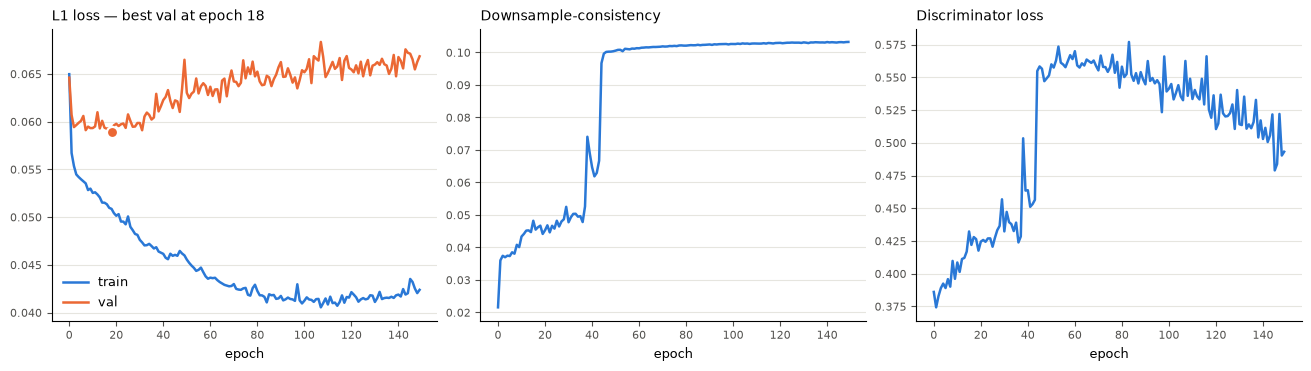

best epoch 18  val_l1 0.05887
final epoch 149  val_l1 0.06684 (+13.6%)


In [9]:
best = min(history, key=lambda r: r["val_l1"])
ep = [r["epoch"] for r in history]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), constrained_layout=True)
BLUE, INK2, GRID = "#2a78d6", "#52514e", "#e6e5df"

axes[0].plot(ep, [r["train_l1"] for r in history], lw=1.8, color=BLUE, label="train")
axes[0].plot(ep, [r["val_l1"] for r in history], lw=1.8, color="#eb6834", label="val")
axes[0].plot([best["epoch"]], [best["val_l1"]], "o", ms=8, color="#eb6834", mec="white", mew=1.6, zorder=5)
axes[0].legend(frameon=False, fontsize=9)
axes[0].set_title(f"L1 loss — best val at epoch {best['epoch']}", fontsize=10, loc="left")

axes[1].plot(ep, [r["consist"] for r in history], lw=1.8, color=BLUE)
axes[1].set_title("Downsample-consistency", fontsize=10, loc="left")

axes[2].plot(ep, [r["d_loss"] for r in history], lw=1.8, color=BLUE)
axes[2].set_title("Discriminator loss", fontsize=10, loc="left")

for ax in axes:
    ax.set_xlabel("epoch", fontsize=9)
    ax.grid(axis="y", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=8, colors=INK2)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
plt.show()

print(f"best epoch {best['epoch']}  val_l1 {best['val_l1']:.5f}")
print(f"final epoch {history[-1]['epoch']}  val_l1 {history[-1]['val_l1']:.5f} "
      f"({100*(history[-1]['val_l1']/best['val_l1']-1):+.1f}%)")

## 4 · Evaluation

Held-out test set, 2022–2025, scored in real mm/day over masked cells only, against
a nearest-upsampled baseline (what you'd get with no model at all).

In [10]:
g = Generator().to(DEVICE)
ck = torch.load(CKPT_DIR / "best.pt", map_location=DEVICE)
g.load_state_dict(ck["g"])
g.eval()
print(f"loaded checkpoint from epoch {ck['epoch']}")


@torch.no_grad()
def predict(dataset, batch=256):
    """Returns (prediction, truth, nearest-baseline) in mm/day."""
    X = torch.stack([dataset[i][0] for i in range(len(dataset))]).to(DEVICE)
    Y = torch.stack([dataset[i][1] for i in range(len(dataset))])
    P = torch.cat([g(X[i:i + batch]) for i in range(0, len(X), batch)]).cpu()
    U = F.interpolate(X[:, :1], scale_factor=FACTOR, mode="nearest").cpu()
    return (scaler.inverse(P.numpy()[:, 0]),
            scaler.inverse(Y.numpy()[:, 0]),
            scaler.inverse(U.numpy()[:, 0]))


def metrics(pred, target):
    p, t = pred[:, mask_bool].ravel(), target[:, mask_bool].ravel()
    return {"mae": float(np.mean(np.abs(p - t))),
            "rmse": float(np.sqrt(np.mean((p - t) ** 2))),
            "bias": float(np.mean(p - t)),
            "corr": float(np.corrcoef(p, t)[0, 1]),
            "r2": float(1 - np.sum((t - p) ** 2) / np.sum((t - t.mean()) ** 2))}


val_pred, val_target, _ = predict(splits["val"])
test_pred, test_target, test_baseline = predict(splits["test"])

loaded checkpoint from epoch 18


In [11]:
raw = metrics(test_pred, test_target)
val_bias = float(np.mean((val_pred - val_target)[:, mask_bool]))
corrected = metrics(np.clip(test_pred - val_bias, 0, None), test_target)
baseline = metrics(test_baseline, test_target)

print(f"=== test 2022-2025 (n={len(splits['test'])}) ===")
print(f"  raw       : MAE={raw['mae']:.2f} RMSE={raw['rmse']:.2f} bias={raw['bias']:+.2f} "
      f"corr={raw['corr']:.3f} R2={raw['r2']:.3f}")
print(f"  bias-corr : MAE={corrected['mae']:.2f} RMSE={corrected['rmse']:.2f} "
      f"bias={corrected['bias']:+.2f} corr={corrected['corr']:.3f} R2={corrected['r2']:.3f} "
      f"(val_bias={val_bias:+.2f})")
print(f"  baseline  : MAE={baseline['mae']:.2f} RMSE={baseline['rmse']:.2f} "
      f"corr={baseline['corr']:.3f} R2={baseline['r2']:.3f}  (nearest upsample, no model)")

(RESULTS / "test_metrics.json").write_text(json.dumps(
    {"raw": raw, "bias_corrected": corrected, "val_bias": val_bias,
     "baseline_nearest_upsample": baseline,
     "n_test_days": len(splits["test"]), "epoch": ck["epoch"]}, indent=2))
print("\nsaved ->", (RESULTS / "test_metrics.json").relative_to(PROJECT))

=== test 2022-2025 (n=1461) ===
  raw       : MAE=2.24 RMSE=7.60 bias=-0.16 corr=0.908 R2=0.821
  bias-corr : MAE=2.32 RMSE=7.60 bias=-0.01 corr=0.908 R2=0.822 (val_bias=-0.15)
  baseline  : MAE=2.53 RMSE=7.12 corr=0.918 R2=0.843  (nearest upsample, no model)

saved -> results/test_metrics.json


Note the bias correction *raises* MAE (2.24 → 2.32) while leaving RMSE flat. It is
computed and reported but not used — raw is the reported configuration.

## 5 · Prediction maps

Naive upsample / GAN output / true CHIRPS side by side for sampled test dates.

> **The defaults reproduce the existing figure, which has a known weakness.**
> `WET_ONLY = False` samples uniformly at random, and Kerala rainfall is
> intermittent, so most sampled days are near-dry. `VMAX_PERCENTILE = 100` scales
> each row by its single wettest cell, which washes the field out on days with one
> extreme value. Setting `WET_ONLY = True` and `VMAX_PERCENTILE = 99` gives a figure
> that actually shows the comparison — see `docs/REPORT.md` finding 8.

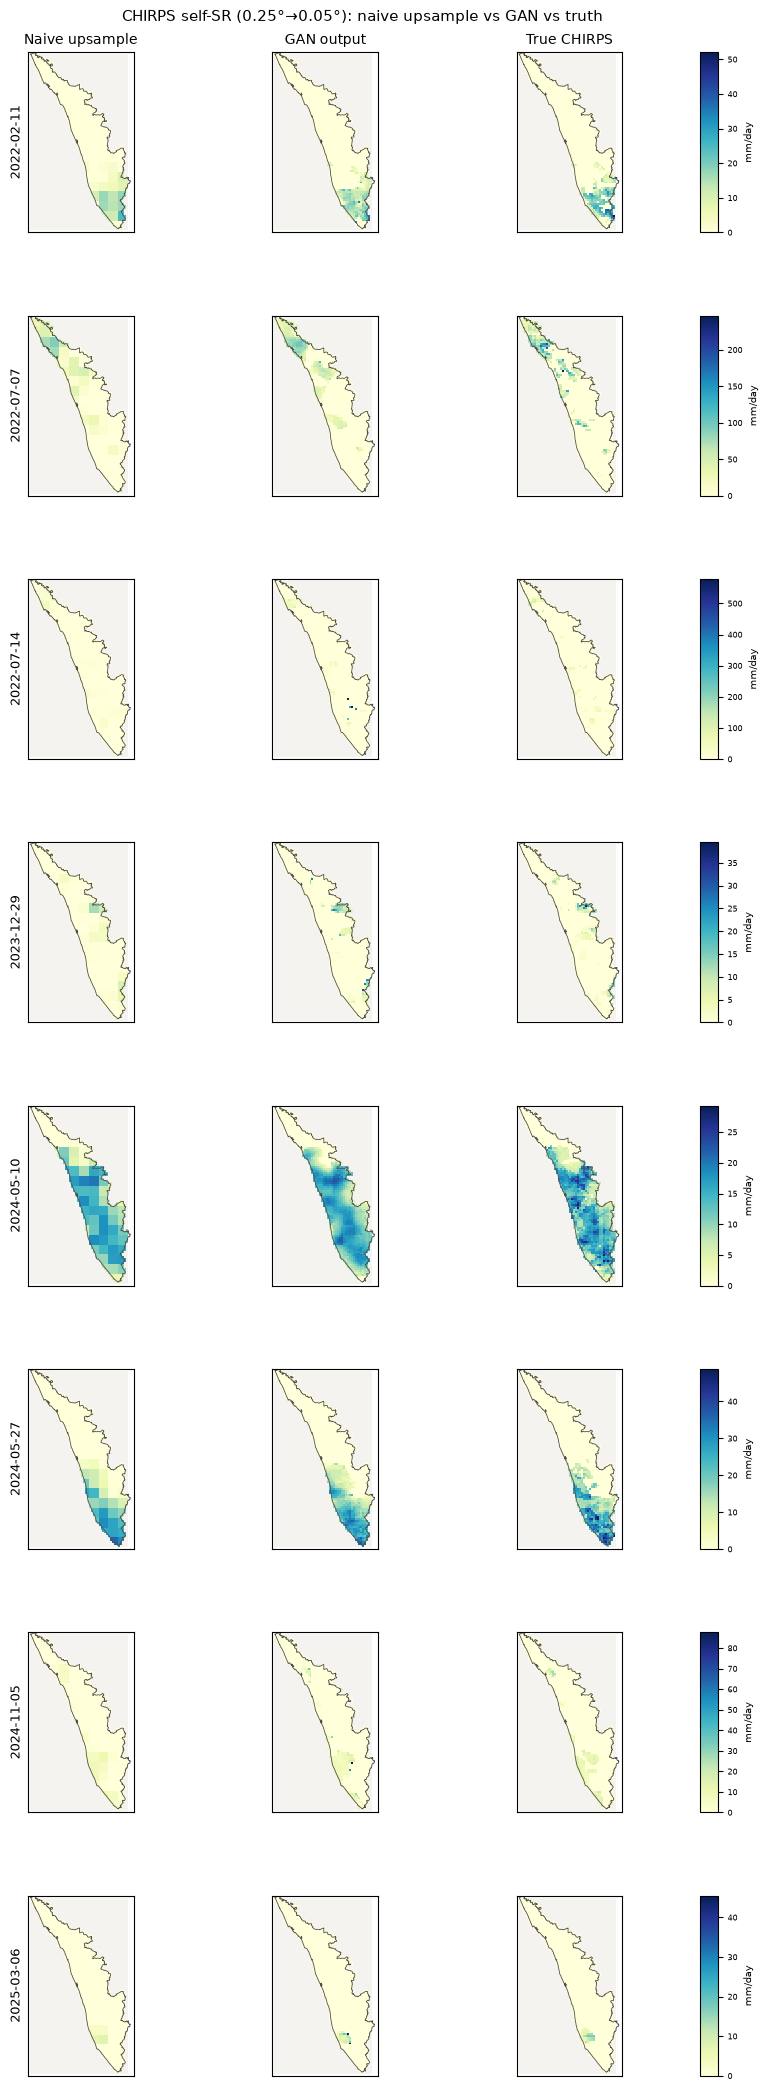

saved -> figures/predicted_vs_actual.png
dates: ['2022-02-11', '2022-07-07', '2022-07-14', '2023-12-29', '2024-05-10', '2024-05-27', '2024-11-05', '2025-03-06']


In [12]:
N_DATES = 8
SEED = 11
WET_ONLY = False        # True -> sample only days above WET_MEAN_MM domain-mean rainfall
WET_MEAN_MM = 5.0
VMAX_PERCENTILE = 100   # 99 keeps one extreme cell from flattening the whole row

test_dates = dates[idx["test"]]
state = gpd.read_file(STATE_GEOJSON)

candidates = np.arange(len(splits["test"]))
if WET_ONLY:
    day_mean = test_target[:, mask_bool].mean(axis=1)
    candidates = candidates[day_mean >= WET_MEAN_MM]
    print(f"{len(candidates)} of {len(test_dates)} test days above {WET_MEAN_MM} mm domain mean")

rng = np.random.default_rng(SEED)
sel = np.sort(rng.choice(candidates, size=min(N_DATES, len(candidates)), replace=False))

cmap = plt.get_cmap("YlGnBu").copy()
cmap.set_bad("#f4f3f0")

fig, axes = plt.subplots(
    len(sel), 4, figsize=(8.0, 2.6 * len(sel)),
    gridspec_kw={"width_ratios": [1, 1, 1, 0.08], "wspace": 0.08, "hspace": 0.3},
    constrained_layout=True)

for row, i in enumerate(sel):
    fields = [("Naive upsample", test_baseline[i]),
              ("GAN output", test_pred[i]),
              ("True CHIRPS", test_target[i])]
    stacked = np.stack([f[mask_bool] for _, f in fields])
    vmax = float(np.percentile(stacked, VMAX_PERCENTILE) if VMAX_PERCENTILE < 100 else stacked.max())

    for col, (title, field) in enumerate(fields):
        ax = axes[row, col]
        pcm = ax.pcolormesh(lon_hr, lat_hr, np.where(mask_bool, field, np.nan),
                            cmap=cmap, vmin=0, vmax=vmax, shading="auto")
        if row == 0:
            ax.set_title(title, fontsize=10)
        state.boundary.plot(ax=ax, color="#52514e", linewidth=0.6)
        ax.set_xlim(74.8, 77.5)
        ax.set_ylim(8.2, 12.8)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])

    axes[row, 0].set_ylabel(str(np.datetime_as_string(test_dates[i], unit="D")),
                            fontsize=9, rotation=90, labelpad=4)
    cbar = fig.colorbar(pcm, cax=axes[row, 3])
    cbar.set_label("mm/day", fontsize=7)
    cbar.ax.tick_params(labelsize=6)

fig.suptitle("CHIRPS self-SR (0.25°→0.05°): naive upsample vs GAN vs truth", fontsize=11)
fig.savefig(FIGURES / "predicted_vs_actual.png", dpi=150, facecolor="white")
plt.show()
print("saved ->", (FIGURES / "predicted_vs_actual.png").relative_to(PROJECT))
print("dates:", [str(np.datetime_as_string(test_dates[i], unit="D")) for i in sel])

## 6 · Diagnostics

The headline MAE/RMSE table can't answer three questions, so these do.

1. **Does the GAN add real sub-grid structure?** Measured as *within-block std* — the
   spatial variability **inside** each 5×5 block, which is exactly the signal
   super-resolution has to invent. Nearest-upsampling has 0.0 by construction.
2. **How well does it place wet and dry cells?** Critical success index at 1 mm/day.
3. **Is the consistency loss measuring what it claims?** Compared against the value a
   *perfect* model would score, from the log-space Jensen gap.

Bilinear is interpolated in **mm space**, not scaled space: smoothing a concave
transform of rainfall is not the same as smoothing rainfall, and mm-space is both
the physically meaningful baseline and the stronger one. (Nearest is unaffected —
replication commutes with any monotone transform.)

In [13]:
WET_THRESH = 1.0  # mm/day

X_test = torch.stack([splits["test"][i][0] for i in range(len(splits["test"]))])
lr_mm = torch.from_numpy(scaler.inverse(X_test[:, :1].numpy()))
test_bilinear = F.interpolate(lr_mm, scale_factor=FACTOR, mode="bilinear",
                              align_corners=False).numpy()[:, 0]

fields = {"true": test_target, "gan": test_pred,
          "nearest": test_baseline, "bilinear": test_bilinear}


def within_block_std(field):
    """Mean spatial std inside each 5x5 block — the sub-grid detail."""
    b = np.where(mask_bool, field, np.nan).reshape(-1, 18, FACTOR, 10, FACTOR)
    with np.errstate(invalid="ignore"):
        return float(np.nanmean(np.nanstd(b, axis=(2, 4))))


def csi(pred, thresh=WET_THRESH):
    p = pred[:, mask_bool].ravel() >= thresh
    t = test_target[:, mask_bool].ravel() >= thresh
    hit, fa, miss = (p & t).sum(), (p & ~t).sum(), (~p & t).sum()
    return {"pod": float(hit / (hit + miss)), "far": float(fa / (hit + fa)),
            "csi": float(hit / (hit + miss + fa)), "wet_freq": float(p.mean())}


# what a PERFECT model scores on the consistency loss (the log-space Jensen gap)
_tr = idx["train"]
_hs = torch.from_numpy(scaler.transform(hr[_tr]).astype("float32"))[:, None]
_ls = torch.from_numpy(scaler.transform(lr[_tr]).astype("float32"))[:, None]
_m = torch.from_numpy(mask_lr.astype("float32"))[None, None]
jensen_floor = float(((F.avg_pool2d(_hs, FACTOR) - _ls).abs() * _m).sum()
                     / _m.expand_as(F.avg_pool2d(_hs, FACTOR)).sum())

_cnt = mask_hr.reshape(18, FACTOR, 10, FACTOR).sum(axis=(1, 3))
_valid = _cnt > 0
del _hs, _ls, _m

In [14]:
diag = {"checkpoint_epoch": int(ck["epoch"]), "n_test_days": len(splits["test"]),
        "wet_threshold_mm": WET_THRESH, "structure": {}, "extremes": {},
        "occurrence": {}, "pointwise": {}}

for name, a in fields.items():
    v = a[:, mask_bool].ravel()
    diag["structure"][name] = within_block_std(a)
    diag["extremes"][name] = {"p99": float(np.percentile(v, 99)),
                              "p999": float(np.percentile(v, 99.9)),
                              "max": float(v.max()), "mean": float(v.mean())}
    if name != "true":
        diag["occurrence"][name] = csi(a)
        diag["pointwise"][name] = metrics(a, test_target)
diag["occurrence"]["true_wet_freq"] = float((test_target[:, mask_bool] >= WET_THRESH).mean())

best = min(history, key=lambda r: r["val_l1"])
diag["training"] = {"epochs_run": len(history), "best_epoch": best["epoch"],
                    "best_val_l1": best["val_l1"], "final_val_l1": history[-1]["val_l1"],
                    "val_degradation_pct": 100 * (history[-1]["val_l1"] / best["val_l1"] - 1),
                    "wasted_epoch_fraction": 1 - (best["epoch"] + 1) / len(history)}
diag["consistency_loss"] = {"perfect_model_floor": jensen_floor,
                            "at_best_epoch": best["consist"], "at_final_epoch": history[-1]["consist"],
                            "valid_blocks": int(_valid.sum()),
                            "full_blocks": int((_cnt == FACTOR ** 2).sum()),
                            "partial_blocks": int(((_cnt > 0) & (_cnt < FACTOR ** 2)).sum()),
                            "partial_fraction": float(((_cnt > 0) & (_cnt < FACTOR ** 2)).sum() / _valid.sum())}

(RESULTS / "diagnostics.json").write_text(json.dumps(diag, indent=2))

hdr = f"{'':<10}{'MAE':>7}{'RMSE':>7}{'corr':>7}{'R2':>7}{'blk-std':>9}{'CSI':>7}{'FAR':>7}{'p99':>8}"
print(hdr); print("-" * len(hdr))
for k in ("gan", "nearest", "bilinear"):
    p, o = diag["pointwise"][k], diag["occurrence"][k]
    print(f"{k:<10}{p['mae']:7.3f}{p['rmse']:7.3f}{p['corr']:7.3f}{p['r2']:7.3f}"
          f"{diag['structure'][k]:9.3f}{o['csi']:7.3f}{o['far']:7.3f}{diag['extremes'][k]['p99']:8.2f}")
print(f"{'TRUE':<10}{'':>7}{'':>7}{'':>7}{'':>7}{diag['structure']['true']:9.3f}"
      f"{'':>7}{'':>7}{diag['extremes']['true']['p99']:8.2f}")
print(f"\ntrue wet-day frequency: {diag['occurrence']['true_wet_freq']:.3f}")
print(f"consistency loss — perfect model would score {jensen_floor:.4f}, "
      f"best epoch scored {best['consist']:.4f}")

              MAE   RMSE   corr     R2  blk-std    CSI    FAR     p99
---------------------------------------------------------------------
gan         2.235  7.600  0.908  0.821    1.854  0.863  0.091   83.45
nearest     2.527  7.117  0.918  0.843    0.000  0.779  0.212   80.50
bilinear    2.554  6.932  0.924  0.851    1.053  0.737  0.257   77.21
TRUE                                      2.872                 87.21

true wet-day frequency: 0.350
consistency loss — perfect model would score 0.1065, best epoch scored 0.0467


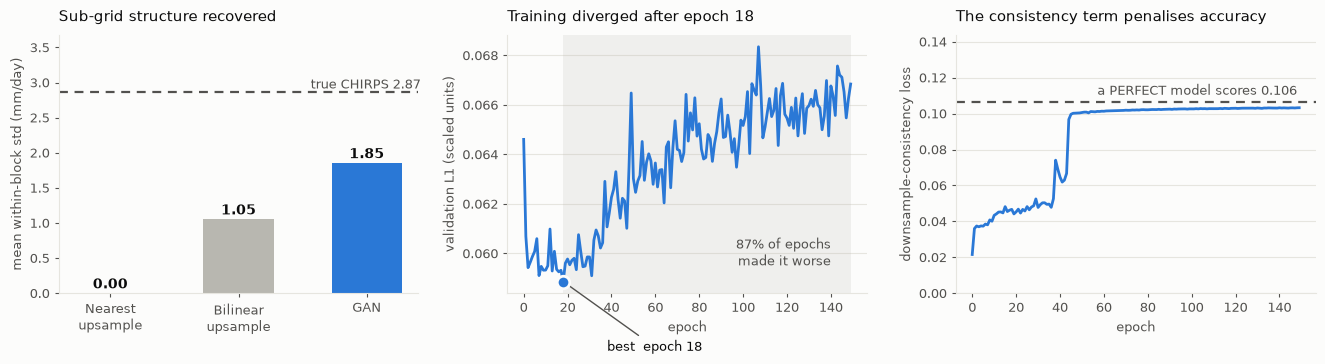

saved -> figures/diagnostics.png
saved -> results/diagnostics.json


In [15]:
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#b8b7b0"
BLUE, SURFACE, GRID = "#2a78d6", "#fcfcfb", "#e6e5df"

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0), facecolor=SURFACE)
for ax in axes:
    ax.set_facecolor(SURFACE)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9, length=3)

# A — sub-grid structure recovered
ax = axes[0]
vals = [diag["structure"][k] for k in ("nearest", "bilinear", "gan")]
bars = ax.bar(["Nearest\nupsample", "Bilinear\nupsample", "GAN"], vals,
              color=[MUTED, MUTED, BLUE], width=0.55)
ref = diag["structure"]["true"]
ax.axhline(ref, ls=(0, (4, 3)), lw=1.6, color=INK2)
ax.text(2.42, ref, f"true CHIRPS {ref:.2f}", va="bottom", ha="right", fontsize=9, color=INK2)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.07, f"{v:.2f}", ha="center",
            fontsize=10, color=INK, fontweight="bold")
ax.set_ylim(0, ref * 1.28)
ax.set_ylabel("mean within-block std (mm/day)", fontsize=9.5, color=INK2)
ax.set_title("Sub-grid structure recovered", fontsize=11, color=INK, pad=10, loc="left")

# B — training diverged early
ax = axes[1]
ax.plot(ep_all := [r["epoch"] for r in history], [r["val_l1"] for r in history], lw=2, color=BLUE)
ax.plot([best["epoch"]], [best["val_l1"]], "o", ms=9, color=BLUE, mec=SURFACE, mew=2, zorder=5)
ax.annotate(f"best  epoch {best['epoch']}", xy=(best["epoch"], best["val_l1"]),
            xytext=(38, best["val_l1"] - 0.0028), fontsize=9.5, color=INK,
            arrowprops=dict(arrowstyle="-", color=INK2, lw=1))
ax.axvspan(best["epoch"], len(history) - 1, color=MUTED, alpha=0.18, lw=0)
ax.text(140, min(r["val_l1"] for r in history) * 1.008,
        f"{diag['training']['wasted_epoch_fraction']*100:.0f}% of epochs\nmade it worse",
        fontsize=9.5, color=INK2, ha="right", va="bottom")
ax.set_xlabel("epoch", fontsize=9.5, color=INK2)
ax.set_ylabel("validation L1 (scaled units)", fontsize=9.5, color=INK2)
ax.set_title(f"Training diverged after epoch {best['epoch']}", fontsize=11, color=INK, pad=10, loc="left")

# C — consistency loss vs its own floor
ax = axes[2]
ax.plot(ep_all, [r["consist"] for r in history], lw=2, color=BLUE)
ax.axhline(jensen_floor, ls=(0, (4, 3)), lw=1.6, color=INK2)
ax.text(len(history) - 2, jensen_floor + 0.004, f"a PERFECT model scores {jensen_floor:.3f}",
        ha="right", fontsize=9.5, color=INK2)
ax.set_ylim(0, jensen_floor * 1.35)
ax.set_xlabel("epoch", fontsize=9.5, color=INK2)
ax.set_ylabel("downsample-consistency loss", fontsize=9.5, color=INK2)
ax.set_title("The consistency term penalises accuracy", fontsize=11, color=INK, pad=10, loc="left")

for ax in axes[1:]:
    ax.grid(axis="y", color=GRID, lw=0.8)
    ax.set_axisbelow(True)

fig.tight_layout(pad=1.6)
fig.savefig(FIGURES / "diagnostics.png", dpi=160, facecolor=SURFACE)
plt.show()
print("saved ->", (FIGURES / "diagnostics.png").relative_to(PROJECT))
print("saved ->", (RESULTS / "diagnostics.json").relative_to(PROJECT))

---

**Reading the numbers.** The GAN recovers ~65% of the true sub-grid variability where
the best interpolation manages 37% and nearest manages none. It is the only method
that keeps wet-day frequency near truth, and the closest at both the 99th and 99.9th
percentile. RMSE and R² go the other way because those metrics reward blur — the
PSNR-versus-perceptual trade-off. Full write-up in `docs/REPORT.md`.